In [6]:
from itertools import combinations
import os
import itertools
import pickle

import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from astropy.stats import circcorrcoef
from matplotlib.lines import Line2D
import matplotlib

from behave_analysis.analyze.filtering_data.filtering_functions import (
    identify_angles,
    filter_video_dataframe,
)


In [7]:
%matplotlib inline

Load tracking data for a single session

In [8]:
JAL1_SEQ3_tracking_data_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\fully_processed_tracking_data.pickle"
with open(JAL1_SEQ3_tracking_data_file, "rb") as f:
    tracking_data = pickle.load(f)

# JAL3 SEQ3
JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
seq3_video_df = pl.read_csv(JAL1_SEQ3_video_df)

In [9]:
def extract_xys_of_arena_objects(trackingData, barrier_present: bool) -> dict:
    """Get X,Y coordinates of the points of interest in the arena. These are not angles, but XY points. 
    They are named as angles so that the variable names can be used as a lookup table for the angles generated"""
    if not barrier_present:
        shelter_location = (
            np.mean([trackingData["shelter_loc"][0][0], trackingData["shelter_loc"][1][0]]),
            np.mean([trackingData["shelter_loc"][0][1], trackingData["shelter_loc"][1][1]]),
        )
        return {"hsa": shelter_location}

    if barrier_present:
        shelter_location = (
            np.mean([trackingData["shelter_loc"][0][0], trackingData["shelter_loc"][1][0]]),
            np.mean([trackingData["shelter_loc"][0][1], trackingData["shelter_loc"][1][1]]),
        )
        preflipLocation = trackingData["barrier_loc"][0]
        centerLocation = trackingData["barrier_loc"][2]
        postflipLocation = trackingData["barrier_loc"][1]
        return {
            "hsa": shelter_location,
            "h_bar_centre_a": centerLocation,
            "h_postflipbar_a": postflipLocation,
            "h_preflipbar_a": preflipLocation,
        }
        
def create_grid() -> tuple:
    """Create a grid of bins in the arena."""
    xs = np.arange(0, 1024, 1)  # 1024 is the size of the arena
    ys = np.arange(0, 1024, 1)
    _, xEdges, yEdges = np.histogram2d(xs, ys, bins=300)
    return xEdges, yEdges

def generate_position_points(xEdges, yEdges, session_height, plotPointsGenerated=False) -> list:
    """Generate X,Y coordinates of the center of each bin in the arena."""
    xCoords = (xEdges[1:] + xEdges[:-1]) / 2  # Find center of bins
    yCoords = (yEdges[1:] + yEdges[:-1]) / 2  # Find center of bins
    xCoords, yCoords = remove_points_away_from_center_of_circle(xCoords, yCoords, session_height)
    positionPoints = [[x, y] for x in xCoords for y in yCoords]  # pack coords

    # Plot the points generated for visualisation purposes and debugging
    if plotPointsGenerated:
        plt.scatter(*zip(*positionPoints))
        plt.grid(True)
        plt.xlabel("X Coordinates")
        plt.ylabel("Y Coordinates")
        plt.title("Plot of Coordinate Pairs")
        plt.show()

    return positionPoints

def remove_points_away_from_center_of_circle(x, y, session_height) -> tuple:
    """
    Ensures there are no positions outside of the areana by removing them from the x and y coordinates based
    on the fact that the radius of the arena is 460 pixels.

    TODO:
    + Make this function global
    + Make the radius of the arena a variable not hard coded
    """

    dist = np.sqrt(
        ((x - session_height / 2) ** 2) + ((y - session_height / 2) ** 2)
    )  # Use the euclidean distance formula to find the distance from the center of the arena
    filtX = x[dist < 460]  # 460 is size of arena circle radius, see register
    filtY = y[dist < 460]
    return filtX, filtY

def compute_the_angle_between_the_head_and_a_point(headPositionDf, pointOfInterest):
    """
    Input:
    + headPosition, (X, Y) coordinates of the head as well as synthetic head direction
    + pointname: the column name of the point you want to compute the angle to in the tracking data e.g barrier location, etc#
    + idx: Some of the columns have multiple index points e.g barrier location has two points so you need to index which one you want

    Expects:
    - angles to be in radians

    Logic:
    - xLen and yLen are the x and y components of the triangle formed by the head and the point of interest
    - Inverse of Tan is used to obtain the angle in radians between the x and y components, arcTan2 is used to ensure 
    the correct quadrant is returned (Unsure why negative is needed)
    - The pos and negative logic is to covert a 270 degree turn into a -90 degree turn
    - Rotate the coordinate plane by 90 degrees to ensure it is in the same coordinate system as the head direction
    - Ensure angle generated is (from pi to -pi) by wrapping values over 180 degrees back to negative
    """

    # Use the inverse of tan to compute the angle between the head and the point of interest
    xLen = -headPositionDf["xY"].apply(lambda x: x[0]) + pointOfInterest[0]
    yLen = -headPositionDf["xY"].apply(lambda x: x[1]) + pointOfInterest[1]
    angleOFInterest = -np.arctan2(yLen, xLen)

    # Ensure a 270 degree turn is converted to a -90 degree turn
    isAngleOFInterestPositive = angleOFInterest > 0
    isAngleOFInterestNegative = angleOFInterest < 0
    angleOFInterest[isAngleOFInterestNegative] += np.pi
    angleOFInterest[isAngleOFInterestPositive] -= np.pi

    # Ensure angle generated is (from pi to -pi)
    adjustedAngleOfInterest = np.pi + (
        angleOFInterest - headPositionDf["hDir"]
    )  # brackets for order of operations its not atuple
    adjustedAngleOfInterest[adjustedAngleOfInterest > np.pi] = adjustedAngleOfInterest[
        adjustedAngleOfInterest > np.pi
    ] - (2 * np.pi)

    return adjustedAngleOfInterest

def generate_hdir_data_for_each_position_point(positionPoints) -> pd.DataFrame:
    """
    Create synthetic head direction data for each position point in the arena.

    Generate a dataframe of all possible combinations of position points and spins.
    This is the function that generates the synthetic head direction data for each
    "grid" or bin in the arena generated from the bin_the_data_create_edges function.
    """
    spins = np.arange(-np.pi, np.pi, 0.1)

    # create an array of all possible combinations of position points and spins
    data = np.array(list(itertools.product(positionPoints, spins)), dtype=object)
    dataframe = pd.DataFrame(data, columns=["xY", "hDir"])
    return dataframe

def create_optimal_distributions(trackingData, session_height) -> dict:
    """Generates the optimal sampling distributions for objs of interest

    Returns:
    -- dict: of pdfs for each point of interest
    """
    barrier = True
    pointsOfInterest = extract_xys_of_arena_objects(trackingData, barrier)
    xEdges, yEdges = create_grid()
    positionPoints = generate_position_points(xEdges, yEdges, session_height)
    hdir_df = generate_hdir_data_for_each_position_point(positionPoints)

    # Gen angles between synthetic hdir and points of interest
    dict = {}
    for _, point in enumerate(pointsOfInterest):
        dict[point] = compute_the_angle_between_the_head_and_a_point(hdir_df, pointsOfInterest[point])
    return dict, hdir_df

def save_optimal_as_csv(dict, hdir_df) -> None:
    """Converts dictionary to csv"""
    df = pl.DataFrame(dict)
    arr = hdir_df["hDir"].to_numpy().astype(float)

    # Ensure the length of 'arr' matches the number of rows in 'df'
    if len(arr) != df.height:
        print(f"The length of 'arr' does not match the number of rows in 'df': {len(arr)} vs {df.height}.")
        return

    large = df.hstack([pl.Series("hdir",arr)]).to_pandas()
    path = "optimal_distributions.csv"
    large.to_csv(path)

Create the optimal distribution

In [10]:
optimal_dictionary, hdir_df = create_optimal_distributions(tracking_data, session_height=1024)
save_optimal_as_csv(optimal_dictionary, hdir_df)

In [11]:
def plot_condition_titles(conditions, nrows, columns) -> None:
    """Plot titles and remove the axes from the first
    column of subplots that act as sub titles"""
    for c_counter, c in enumerate(conditions):
        ax = plt.subplot(nrows, columns, c_counter * columns + 1)
        ax.text(1, 0.5, c, rotation="horizontal", va="center", ha="center", fontsize=20)
        ax.set_axis_off()

def load_optimals():
    """Load the optimal angles for synth mouse"""
    return pl.read_csv("optimal_distributions.csv")

def create_all_the_permutations_of_angles(columns) -> list:
    """Permutate a list of angle strings"""
    return list(combinations(columns, 2))

def loop_permutations_apply_circcoeff(combinations, video_df) -> dict:
    """Apply coeff to all permutations of angles"""
    rhoDict = {}
    for angle_set in combinations:
        alpha = np.array(video_df[angle_set[0]].to_numpy())
        beta = np.array(video_df[angle_set[1]].to_numpy())
        rho = circcorrcoef(alpha, beta)
        rhoDict[angle_set] = rho
    return rhoDict

In [12]:
angles = ['hdir', 'hsa', 'h_bar_centre_a', 'h_postflipbar_a', 'h_preflipbar_a']
#conditions = ["shelter_only", "barrier_present"]
conditions = ["barrier_present"]

In [13]:
def plot_the_circular_rho(video_df, condition="barrier_present"):
    """Publication-ready: Compare circular rho for sampled vs optimal distributions for a single condition."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # Define angles without the center angle
    angles_without_center = ['hdir', 'hsa', 'h_postflipbar_a', 'h_preflipbar_a']
    
    # Create mapping for display names
    display_names = {
        'hdir': 'Head Direction',
        'hsa': 'Shelter',
        'h_postflipbar_a': 'Left Edge',
        'h_preflipbar_a': 'Right Edge'
    }

    perms = list(combinations(angles_without_center, 2))

    # Create optimal rho dict
    optimals = load_optimals()
    optimal_rho_dic = loop_permutations_apply_circcoeff(perms, optimals)
    optimal_rhos = list(optimal_rho_dic.values())
    
    # Create readable labels using the display names
    x_labels = [f"{display_names[perms[i][0]]} vs {display_names[perms[i][1]]}" for i in range(len(perms))]

    # Publication colors (colorblind-friendly)
    real_color = "#0072B2"      # Blue
    optimal_color = "#E69F00"   # Orange

    # Font sizes
    axis_label_size = 22
    tick_label_size = 18
    legend_size = 20

    fig, ax = plt.subplots(figsize=(14, 6))

    # compute data
    data = filter_video_dataframe(video_df, condition)
    rho_dic = loop_permutations_apply_circcoeff(perms, data)
    real_rhos = list(rho_dic.values())

    x = np.arange(len(x_labels))  # the label locations

    # Plot the bar chart
    ax.bar(
        x - 0.15, real_rhos, color=real_color, edgecolor='black', label="Sampled", width=0.3
    )
    ax.bar(
        x + 0.15, optimal_rhos, color=optimal_color, edgecolor='black', label="Optimal", width=0.3
    )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15, ha='right', fontsize=tick_label_size)
    ax.set_ylabel("Circular correlation (ρ)", fontsize=axis_label_size, fontweight='bold')
    ax.set_ylim(-1.05, 1.05)
    ax.axhline(0, linewidth=1.5, color="black", linestyle="--")
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=tick_label_size)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=7)

    legend_elements = [
        Line2D([0], [0], color=real_color, lw=8, label="Sampled Distribution"),
        Line2D([0], [0], color=optimal_color, lw=8, label="Optimal Distribution"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=2,
        fontsize=legend_size,
        frameon=False,
    )

    plt.tight_layout(pad=0.7, w_pad=0.2, h_pad=0.7)
    plt.subplots_adjust(left=0.08, right=0.98, bottom=0.13, top=0.88)
    
    # Save the figure
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    fig.savefig(os.path.join(save_path, "circular_rho_comparison.eps"), format="eps", bbox_inches="tight", dpi=300)
    
    plt.show()

In [14]:
# plot mapltloib inlinei n Jupyter Notebook
%matplotlib inline

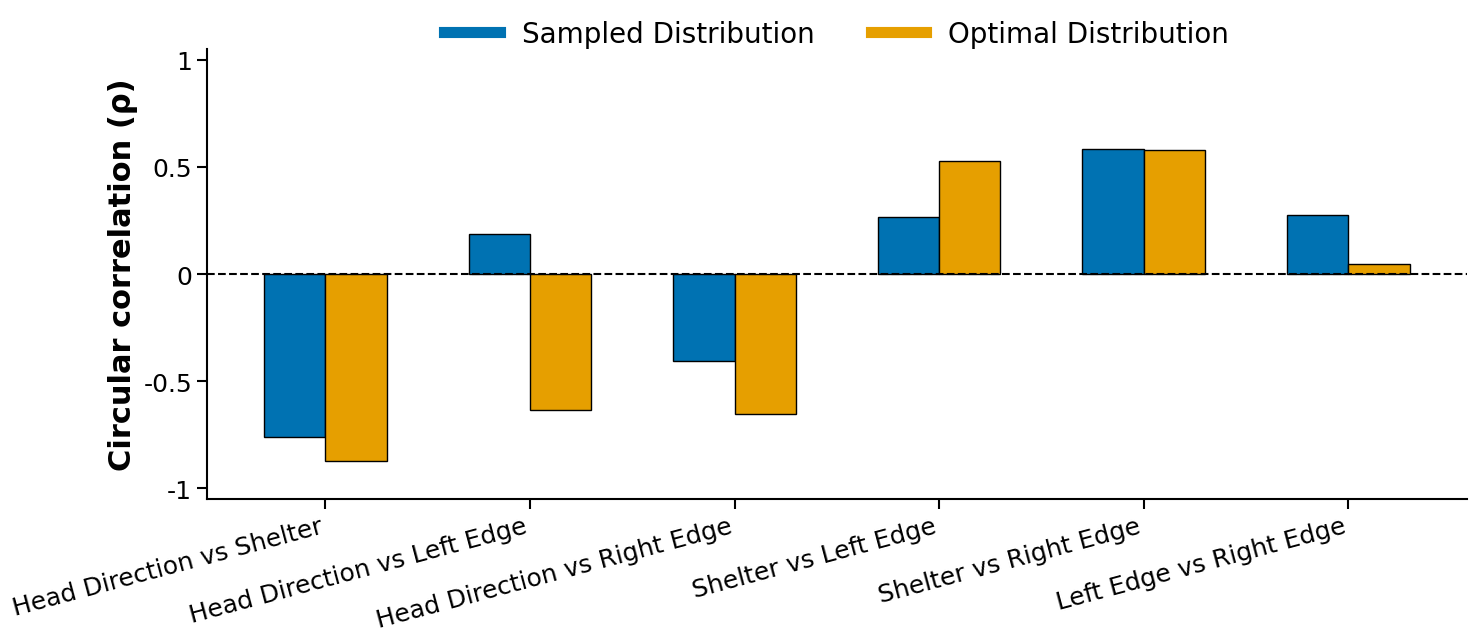

In [15]:
plot_the_circular_rho(seq3_video_df, conditions)

In [16]:
def plot_circular_rho_heatmap(video_df, condition="barrier_present"):
    """
    Plot a heatmap matrix of circular rho values for all angle pairs for a single condition.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    perms = create_all_the_permutations_of_angles(angles)
    optimals = load_optimals()
    optimal_rho_dic = loop_permutations_apply_circcoeff(perms, optimals)
    data = filter_video_dataframe(video_df, condition)
    real_rho_dic = loop_permutations_apply_circcoeff(perms, data)

    # Prepare square matrices for heatmap
    angle_labels = angles
    n = len(angle_labels)
    real_matrix = np.full((n, n), np.nan)
    optimal_matrix = np.full((n, n), np.nan)

    # Fill upper triangle with real, lower with optimal
    for (a, b), rho in real_rho_dic.items():
        i, j = angle_labels.index(a), angle_labels.index(b)
        real_matrix[i, j] = rho
    for (a, b), rho in optimal_rho_dic.items():
        i, j = angle_labels.index(a), angle_labels.index(b)
        optimal_matrix[j, i] = rho

    # Combine for a single heatmap (upper=real, lower=optimal)
    combined = np.where(~np.isnan(real_matrix), real_matrix, optimal_matrix)
    mask = np.zeros_like(combined, dtype=bool)
    mask[np.tril_indices_from(mask, -1)] = True  # mask lower triangle for real
    mask[np.triu_indices_from(mask, 1)] = True   # mask upper triangle for optimal

    fig, ax = plt.subplots(figsize=(8, 7))
    # Plot real (upper triangle)
    sns.heatmap(real_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=angle_labels, yticklabels=angle_labels, mask=np.tril(np.ones_like(real_matrix, dtype=bool), -1),
                cbar=False, ax=ax, annot_kws={"fontsize":14})
    # Plot optimal (lower triangle)
    sns.heatmap(optimal_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=angle_labels, yticklabels=angle_labels, mask=np.triu(np.ones_like(optimal_matrix, dtype=bool), 1),
                cbar=True, ax=ax, annot_kws={"fontsize":14})

    ax.set_title(f"Circular correlation (ρ) matrix: {condition}", fontsize=20, fontweight='bold', pad=20)
    ax.set_xticklabels(angle_labels, rotation=25, ha='right', fontsize=16, fontweight='bold')
    ax.set_yticklabels(angle_labels, rotation=0, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='both', length=0)
    cbar = ax.collections[-1].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label("Circular ρ", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # save the heatmap as an eps
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    
    fig.savefig(
        os.path.join(save_path, f"circular_rho_heatmap.eps"),
        format="eps",
        bbox_inches="tight",
        dpi=300,
    )


In [17]:
def plot_circular_rho_heatmap(video_df, condition="barrier_present"):
    """
    Plot a heatmap matrix of circular rho values for all angle pairs for a single condition.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    # Define angles without the center angle
    angles_to_use = ['hdir', 'hsa', 'h_postflipbar_a', 'h_preflipbar_a']
    
    # Create display name mapping
    display_names = {
        'hdir': 'Head Direction',
        'hsa': 'Shelter',
        'h_postflipbar_a': 'Right Edge',
        'h_preflipbar_a': 'Left Edge'
    }
    
    perms = create_all_the_permutations_of_angles(angles_to_use)
    optimals = load_optimals()
    optimal_rho_dic = loop_permutations_apply_circcoeff(perms, optimals)
    data = filter_video_dataframe(video_df, condition)
    real_rho_dic = loop_permutations_apply_circcoeff(perms, data)

    # Prepare square matrices for heatmap
    n = len(angles_to_use)
    real_matrix = np.full((n, n), np.nan)
    optimal_matrix = np.full((n, n), np.nan)

    # Fill upper triangle with real, lower with optimal
    for (a, b), rho in real_rho_dic.items():
        i, j = angles_to_use.index(a), angles_to_use.index(b)
        real_matrix[i, j] = rho
    for (a, b), rho in optimal_rho_dic.items():
        i, j = angles_to_use.index(a), angles_to_use.index(b)
        optimal_matrix[j, i] = rho

    # Create display labels using the mapping
    display_labels = [display_names[a] for a in angles_to_use]
    
    # Create a square figure with proper spacing
    fig, ax = plt.subplots(figsize=(8, 7))  # Make figure square
    
    # Plot real (upper triangle)
    sns.heatmap(real_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=display_labels, yticklabels=display_labels, 
                mask=np.tril(np.ones_like(real_matrix, dtype=bool), -1),
                cbar=False, ax=ax, annot_kws={"fontsize":14})
    
    # Plot optimal (lower triangle)
    sns.heatmap(optimal_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=display_labels, yticklabels=display_labels, 
                mask=np.triu(np.ones_like(optimal_matrix, dtype=bool), 1),
                cbar=True, ax=ax, annot_kws={"fontsize":14})

    ax.set_title(f"Circular correlation (ρ) matrix: {condition}", fontsize=20, fontweight='bold', pad=20)
    
    # Adjust tick labels placement
    ax.set_xticklabels(display_labels, rotation=20, ha='right', fontsize=16, fontweight='bold')
    ax.set_yticklabels(display_labels, rotation=0, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='both', length=0)
    
    # Add colorbar label
    cbar = ax.collections[-1].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label("Circular ρ", fontsize=16, fontweight='bold')
    
    # Add a note about the triangles - place it below the plot with more space
    plt.figtext(0.5, 0.00001, "Upper triangle: Sampled distribution • Lower triangle: Optimal distribution", 
                ha="center", fontsize=12, fontstyle='italic')
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)  # Add more space at the bottom for the text
    
    # save the heatmap as an eps
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    
    fig.savefig(
        os.path.join(save_path, f"circular_rho_heatmap.eps"),
        format="eps", bbox_inches="tight", dpi=300,
    )
    fig.savefig(
        os.path.join(save_path, f"circular_rho_heatmap.png"),
        format="png", bbox_inches="tight", dpi=300,
    )
    
    plt.show()

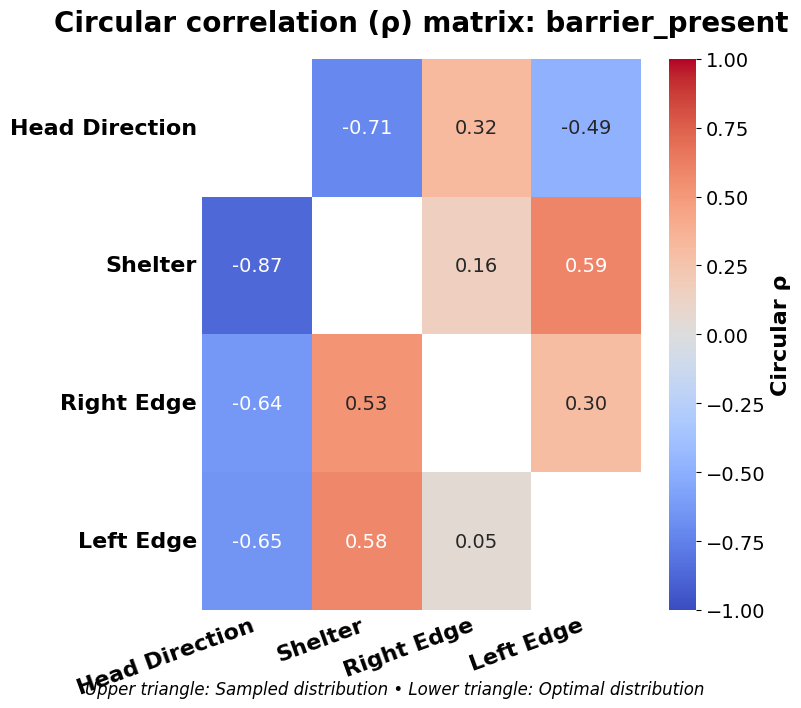

In [18]:
plot_circular_rho_heatmap(seq3_video_df, condition="barrier_present")

In [19]:
def plot_circular_correlation_explainer():
    """
    Creates a simplified figure that explains circular correlation coefficients.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    from matplotlib.lines import Line2D
    from matplotlib import cm
    
    # Set up figure with subplots
    fig = plt.figure(figsize=(15, 5))
    
    # Define grid for subplots
    gs = fig.add_gridspec(1, 3)
    
    # Define color scheme
    main_color = "#0072B2"  # Dark blue
    highlight_color = "#E69F00"  # Orange
    
    # Font sizes
    title_size = 18
    axis_label_size = 14
    annotation_size = 12
   
    # 1. Circular data visualization (left)
    ax1 = fig.add_subplot(gs[0, 0], projection='polar')
    
    # Generate correlated circular data
    theta1 = np.linspace(0, 2*np.pi, 100)
    theta2 = theta1 + np.random.normal(0, 0.3, 100)  # Correlated with some noise
    
    # Ensure angles are in [-π, π]
    theta2 = np.mod(theta2 + np.pi, 2*np.pi) - np.pi
    
    # Plot points on circle
    ax1.scatter(theta1, np.ones_like(theta1), c=main_color, alpha=0.6, label='Variable 1')
    ax1.scatter(theta2, 0.4*np.ones_like(theta2), c=highlight_color, alpha=0.6, label='Variable 2')
    
    # Remove radial ticks and adjust grid
    ax1.set_rticks([])
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Circular Variables', fontsize=title_size)
    
    # Add legend
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)
    
    # 2. Circular correlation concept (middle)
    ax2 = fig.add_subplot(gs[0, 1], projection='polar')
    
    # Generate positively correlated data
    theta1 = np.linspace(0, 2*np.pi, 20)
    theta2 = theta1 + np.random.normal(0, 0.3, 20)
    
    # Ensure angles are in [-π, π]
    theta2 = np.mod(theta2 + np.pi, 2*np.pi) - np.pi
    
    # Plot arrows showing difference
    for i in range(len(theta1)):
        ax2.annotate("", xy=(theta1[i], 1), xytext=(theta2[i], 0.6),
                    arrowprops=dict(arrowstyle="->", color=highlight_color, alpha=0.6, lw=1.5))
    
    # Plot points
    ax2.scatter(theta1, np.ones_like(theta1), c=main_color, s=50)
    ax2.scatter(theta2, 0.6*np.ones_like(theta2), c=highlight_color, s=50)
    
    ax2.set_rticks([])
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Positive Correlation (ρ ≈ 0.9)', fontsize=title_size)
    
    # 3. Circular correlation scale (right)
    ax3 = fig.add_subplot(gs[0, 2])
    
    # Create a horizontal color gradient showing correlation scale
    gradient = np.linspace(-1, 1, 100).reshape(1, -1)
    ax3.imshow(gradient, cmap='coolwarm', aspect='auto', extent=[-1, 1, 0, 1])
    ax3.set_yticks([])
    ax3.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax3.set_xticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=12)
    ax3.set_xlabel('Circular Correlation Coefficient (ρ)', fontsize=axis_label_size)
    ax3.set_title('Interpretation Scale', fontsize=title_size)
    
    # Add annotations
    ax3.annotate('Perfect negative\ncorrelation', xy=(-0.9, 0.5), xytext=(-0.9, 1.3),
                arrowprops=dict(arrowstyle="->", color='black'), ha='center', fontsize=annotation_size)
    ax3.annotate('No correlation', xy=(0, 0.5), xytext=(0, 1.3),
                arrowprops=dict(arrowstyle="->", color='black'), ha='center', fontsize=annotation_size)
    ax3.annotate('Perfect positive\ncorrelation', xy=(0.9, 0.5), xytext=(0.9, 1.3),
                arrowprops=dict(arrowstyle="->", color='black'), ha='center', fontsize=annotation_size)
    
    # Removed overall title and bottom text
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    
    # Save figure
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    plt.savefig(os.path.join(save_path, "circular_correlation_explainer.eps"), 
               format="eps", bbox_inches="tight", dpi=300)
    
    plt.show()
    
    return fig

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


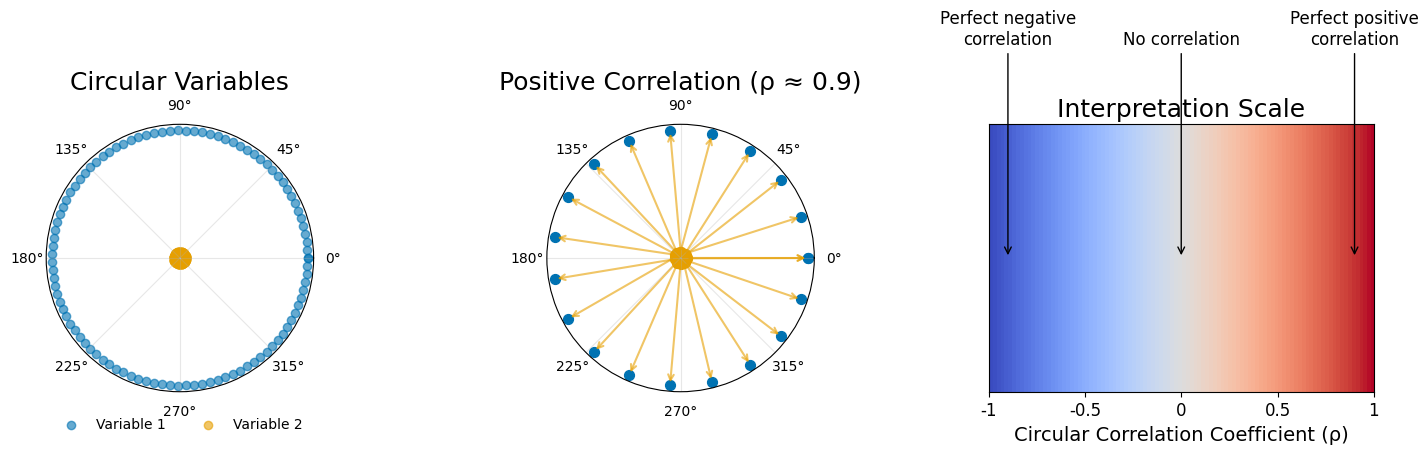

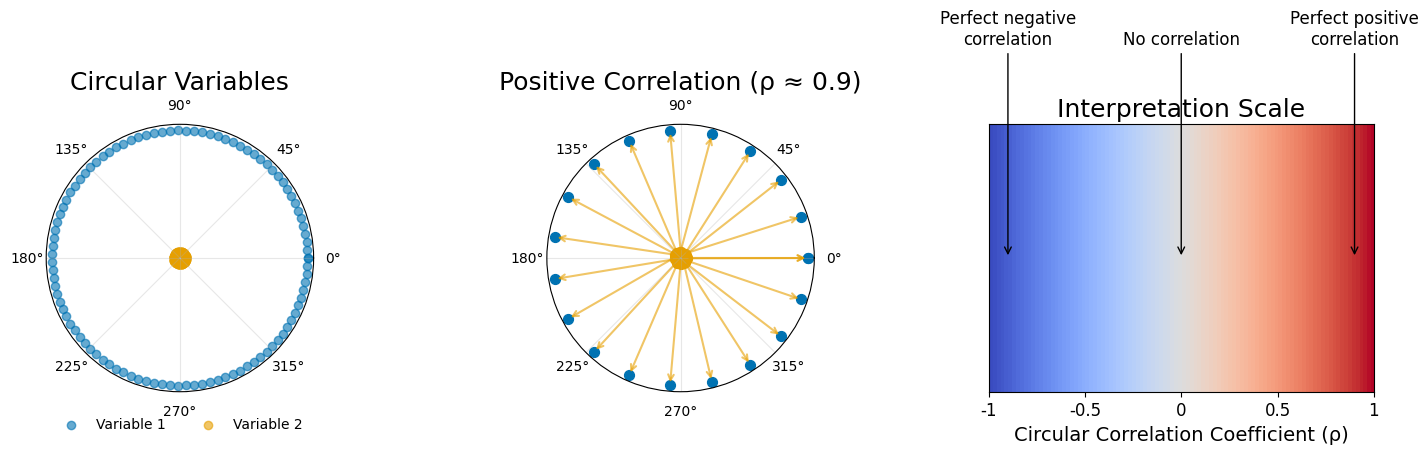

In [20]:
plot_circular_correlation_explainer()

# Across session correlations

Calculating circular correlations for each session...

Pair: Head Direction vs Shelter
  Real correlation (mean ± SEM): 0.182 ± 0.301
  Optimal correlation: -0.873
  P-value: 0.0395
  Significant difference: Yes
  Individual session values: ['-0.715', '0.566', '0.377', '0.497']

Pair: Head Direction vs Left Edge
  Real correlation (mean ± SEM): -0.067 ± 0.151
  Optimal correlation: -0.635
  P-value: 0.0330
  Significant difference: Yes
  Individual session values: ['0.315', '-0.227', '0.020', '-0.376']

Pair: Head Direction vs Right Edge
  Real correlation (mean ± SEM): -0.251 ± 0.179
  Optimal correlation: -0.654
  P-value: 0.1098
  Significant difference: No
  Individual session values: ['-0.486', '0.249', '-0.236', '-0.531']

Pair: Shelter vs Left Edge
  Real correlation (mean ± SEM): 0.279 ± 0.055
  Optimal correlation: 0.526
  P-value: 0.0201
  Significant difference: Yes
  Individual session values: ['0.164', '0.424', '0.286', '0.243']

Pair: Shelter vs Right Edge
  Real correlat

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Figure saved to: Z:\Laurence\thesis\figures\two_edge_paradigm


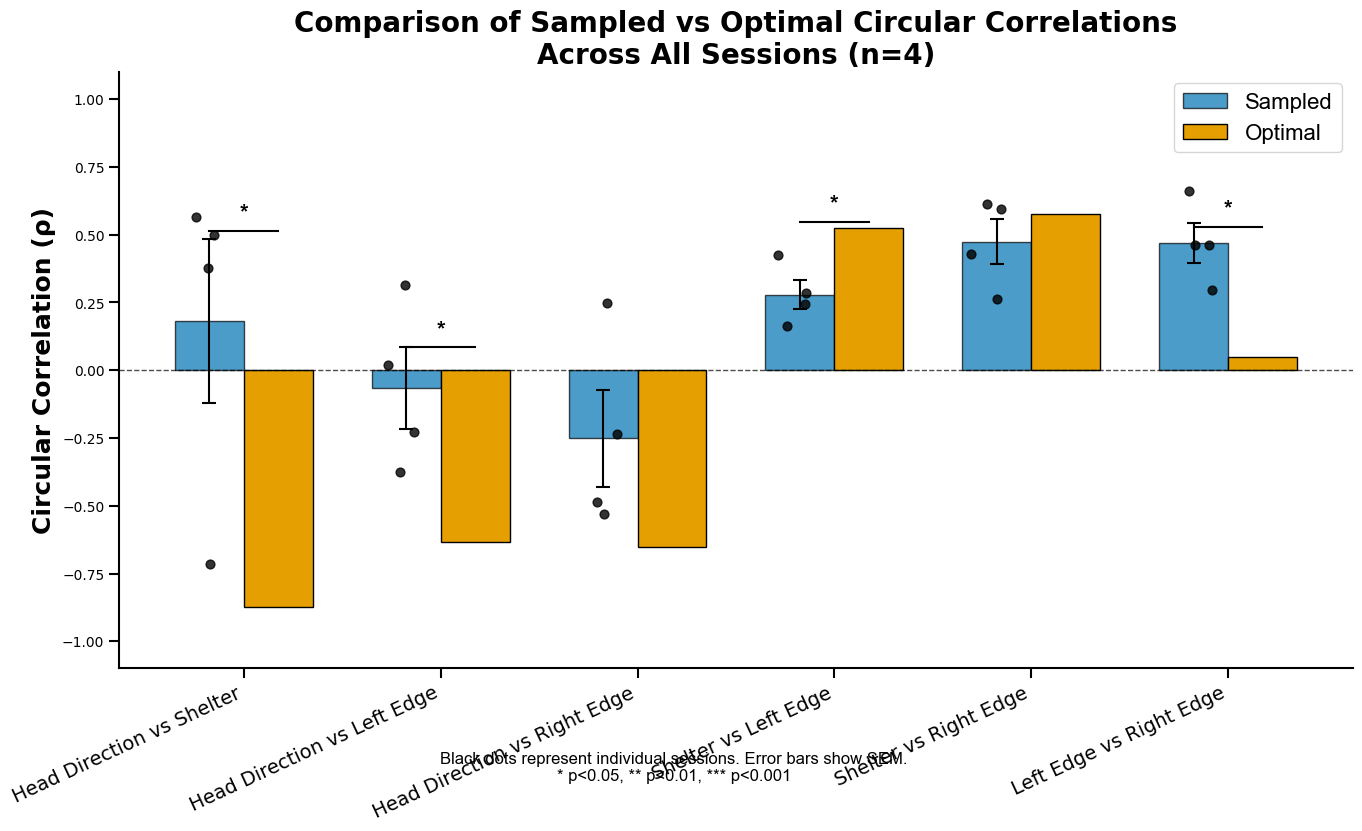

In [21]:
def analyze_circular_correlations_across_sessions():
    """
    Compare circular correlations between real and optimal distributions across all sessions.
    Performs statistical analysis and creates a comprehensive visualization.
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import scipy.stats as stats
    from itertools import combinations
    
    # Load data from all sessions
    # JAL1 SEQ3
    JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
    seq3_video_df = pl.read_csv(JAL1_SEQ3_video_df)

    # JAL1 SEQ2
    JAL1_SEQ2_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\full_video_dataframe.csv" 
    seq2_video_df = pl.read_csv(JAL1_SEQ2_video_df)

    # JAL2 SEQ2
    JAL2_SEQ2_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\full_video_dataframe.csv"
    jal2_seq2_df = pl.read_csv(JAL2_SEQ2_video_df)

    # JAl2 SEQ3
    JAL2_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\full_video_dataframe.csv"
    jal2_seq3_df = pl.read_csv(JAL2_SEQ3_video_df)
    
    # Define the condition and angles we're interested in
    condition = "barrier_present"
    angles_without_center = ['hdir', 'hsa', 'h_postflipbar_a', 'h_preflipbar_a']
    
    # Create better display names for angles
    display_names = {
        'hdir': 'Head Direction',
        'hsa': 'Shelter',
        'h_postflipbar_a': 'Left Edge',
        'h_preflipbar_a': 'Right Edge'
    }
    
    # Create all permutations of angles
    perms = list(combinations(angles_without_center, 2))
    
    # Load optimal correlations
    optimals = load_optimals()
    optimal_rho_dic = loop_permutations_apply_circcoeff(perms, optimals)
    
    # Calculate correlations for each session
    session_dfs = [seq3_video_df, seq2_video_df, jal2_seq2_df, jal2_seq3_df]
    session_names = ["JAL1-SEQ3", "JAL1-SEQ2", "JAL2-SEQ2", "JAL2-SEQ3"]
    session_rhos = []
    
    print("Calculating circular correlations for each session...")
    for i, session_df in enumerate(session_dfs):
        data = filter_video_dataframe(session_df, condition)
        rho_dic = loop_permutations_apply_circcoeff(perms, data)
        session_rhos.append(rho_dic)
        
    # Create readable labels for pairs
    pair_labels = []
    for perm in perms:
        pair_labels.append(f"{display_names[perm[0]]} vs {display_names[perm[1]]}")
    
    # For each pair, collect real and optimal correlations across sessions
    pair_data = {}
    for perm in perms:
        pair = perm
        real_vals = [session_rho.get(pair, np.nan) for session_rho in session_rhos]
        optimal_val = optimal_rho_dic[pair]
        
        # Calculate mean, standard error, and p-value (one-sample t-test against optimal)
        mean_real = np.mean(real_vals)
        sem_real = np.std(real_vals, ddof=1) / np.sqrt(len(real_vals))
        t_stat, p_val = stats.ttest_1samp(real_vals, optimal_val)
        
        pair_data[pair] = {
            'real_values': real_vals,
            'real_mean': mean_real,
            'real_sem': sem_real,
            'optimal': optimal_val,
            'p_value': p_val,
            'display_label': f"{display_names[pair[0]]} vs {display_names[pair[1]]}"
        }
        
        # Print statistical results
        print(f"\nPair: {display_names[pair[0]]} vs {display_names[pair[1]]}")
        print(f"  Real correlation (mean ± SEM): {mean_real:.3f} ± {sem_real:.3f}")
        print(f"  Optimal correlation: {optimal_val:.3f}")
        print(f"  P-value: {p_val:.4f}")
        print(f"  Significant difference: {'Yes' if p_val < 0.05 else 'No'}")
        print(f"  Individual session values: {[f'{val:.3f}' for val in real_vals]}")
    
    # Set up plotting parameters
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(pair_labels))
    width = 0.35
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    })
    
    # Plot bars
    real_bars = ax.bar(x - width/2, 
                       [pair_data[pair]['real_mean'] for pair in perms], 
                       width, label='Sampled', color='#0072B2', edgecolor='black', alpha=0.7)
    
    optimal_bars = ax.bar(x + width/2, 
                          [pair_data[pair]['optimal'] for pair in perms], 
                          width, label='Optimal', color='#E69F00', edgecolor='black')
    
    # Add individual data points with jitter
    for i, pair in enumerate(perms):
        # Add jitter to x positions
        x_jitter = np.random.normal(0, 0.05, size=len(pair_data[pair]['real_values']))
        ax.scatter(x[i] - width/2 + x_jitter, 
                   pair_data[pair]['real_values'], 
                   color='black', s=40, alpha=0.8, zorder=3)
    
    # Add error bars for real data
    ax.errorbar(x - width/2, 
                [pair_data[pair]['real_mean'] for pair in perms],
                yerr=[pair_data[pair]['real_sem'] for pair in perms], 
                fmt='none', color='black', capsize=5, capthick=1.5, zorder=4)
    
    # Add statistical significance indicators
    for i, pair in enumerate(perms):
        p = pair_data[pair]['p_value']
        y_pos = max(pair_data[pair]['real_mean'] + pair_data[pair]['real_sem'] * 1.2, 
                     pair_data[pair]['optimal'] + 0.05)
        
        # Add significance stars
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = "n.s."
        
        # Add connector line for significant results
        if sig != "n.s.":
            ax.plot([x[i] - width/2, x[i] + width/2], 
                    [y_pos - 0.03, y_pos - 0.03], 
                    'k-', linewidth=1.5)
            ax.text(x[i], y_pos, sig, ha='center', va='bottom', 
                    fontweight='bold', fontsize=16)
    
    # Configure axes
    ax.set_ylabel('Circular Correlation (ρ)', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, rotation=25, ha='right', fontsize=14)
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=7)
    
    # Add legend
    ax.legend(fontsize=16, frameon=True, loc='upper right')
    
    # Add title
    ax.set_title('Comparison of Sampled vs Optimal Circular Correlations\nAcross All Sessions (n=4)', 
                fontsize=20, fontweight='bold')
    
    # Add note about sessions
    plt.figtext(0.5, 0.01, 'Black dots represent individual sessions. Error bars show SEM.\n* p<0.05, ** p<0.01, *** p<0.001', 
               ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    # Save figure
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "circular_correlation_across_sessions.eps"), 
               format="eps", bbox_inches="tight", dpi=300)
    plt.savefig(os.path.join(save_path, "circular_correlation_across_sessions.png"), 
               format="png", bbox_inches="tight", dpi=300)
    plt.savefig(os.path.join(save_path, "circular_correlation_across_sessions.pdf"), 
               format="pdf", bbox_inches="tight", dpi=300)
    
    print("\nFigure saved to:", save_path)
    return fig, ax, pair_data

# Run the analysis
import polars as pl
import numpy as np
fig, ax, pair_data = analyze_circular_correlations_across_sessions()

In [28]:
# Function to find all session directories
import glob
def find_all_sessions(base_path="Z:/Jasmine_Laurence/Experimental_Data"):
    """Find all session directories in the base path"""
    session_paths = []
    
    # Look for JAL directories
    mouse_dirs = glob.glob(os.path.join(base_path, "JAL*"))
    
    for mouse_dir in mouse_dirs:
        # Find all session directories within each mouse directory
        sessions = glob.glob(os.path.join(mouse_dir, "*"))
        for session in sessions:
            # Check if it's a directory and contains processed_data
            if os.path.isdir(session) and os.path.exists(os.path.join(session, "processed_data")):
                session_paths.append(session)
    
    return session_paths

Found 9 two-edge sessions and 38 one-edge sessions

Processing two-edge sessions...
  Skipping 001_mushroom3_2023_03_15T07_43_42 - no video dataframe found
  Processed 001_seq1_2_2023_03_14T08_11_32
  Processed 001_seq1_3_2023_03_17T08_38_03
  Skipping 002_mushroom1_2023_04_21T08_24_45 - no video dataframe found


c:\Users\laurence\miniconda3\envs\JAL2pipeline\lib\site-packages\astropy\stats\circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
c:\Users\laurence\miniconda3\envs\JAL2pipeline\lib\site-packages\astropy\stats\circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)
c:\Users\laurence\miniconda3\envs\JAL2pipeline\lib\site-packages\astropy\stats\circstats.py:353: RuntimeWarning: invalid value encountered in scalar divide
  rho = np.sum(sin_a * sin_b) / np.sqrt(np.sum(sin_a * sin_a) * np.sum(sin_b * sin_b))


  Error processing 002_mushroom3_2023_04_27T08_30_15: "h_postflipbar_a" not found
  Skipping 002_mushroom4_2023_05_01T08_16_14 - no video dataframe found
  Processed 002_seq1_2_2023_04_25T07_32_30
  Skipping 002_Sequence1_2023_04_22T08_38_41 - no video dataframe found
  Processed 002_Sequence1_3_2023_04_28T08_31_30

Processing one-edge sessions...
  Processed 004_baseline_2023_08_17T13_41_44
  Processed 004_flipppuf19sept_2023_09_19T14_10_56
  Processed 004_flip_2023_09_03T12_04_16
  Processed 004_flip_puff2_2023_09_11T09_32_25
  Skipping 004_mush1_2023_08_22T13_13_41 - no video dataframe found
  Processed JAL004_flip_rotated_2023_08_28T09_36_04
  Processed 003_003puftrotato3_2023_09_07T12_23_47
  Processed 003_baseline_2023_08_17T08_16_46
  Processed 003_flippuff2_2023_09_04T13_38_31
  Processed 003_flip_1Sept_2023_09_01T16_23_39
  Processed 003_flip_2023_08_22T08_04_56
  Processed 003_flip_rotated_2023_08_25T09_42_06
  Processed JAL008_empty_shelter2_2024_04_22T10_51_22
  Processed J

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Error processing 005_mushy1_2023_10_03T08_11_08: "h_postflipbar_a" not found

Pair statistics:

Pair: Head Direction vs Shelter
  Two-edge mean ± SEM: 0.182 ± 0.301 (n=4)
  One-edge mean ± SEM: -0.600 ± 0.058 (n=28)
  p-value: 0.0783
  Significant difference: No
  Two-edge values: ['0.566', '-0.715', '0.377', '0.497']
  One-edge values: ['-0.688', '-0.717', '-0.812', '-0.745', '-0.794', '-0.799', '-0.651', '-0.817', '-0.807', '-0.852', '-0.811', '-0.779', '-0.865', '-0.769', '-0.743', '-0.691', '-0.582', '-0.642', '-0.590', '0.068', '-0.590', '-0.436', '-0.340', '-0.339', '-0.666', '0.417', '0.009', '-0.761']

Pair: Head Direction vs Left Edge
  Two-edge mean ± SEM: -0.067 ± 0.151 (n=4)
  One-edge mean ± SEM: -0.236 ± 0.054 (n=28)
  p-value: 0.3560
  Significant difference: No
  Two-edge values: ['-0.227', '0.315', '0.020', '-0.376']
  One-edge values: ['0.285', '-0.611', '-0.205', '-0.313', '-0.229', '-0.201', '-0.484', '-0.337', '-0.660', '-0.500', '-0.290', '-0.331', '-0.682', '-0

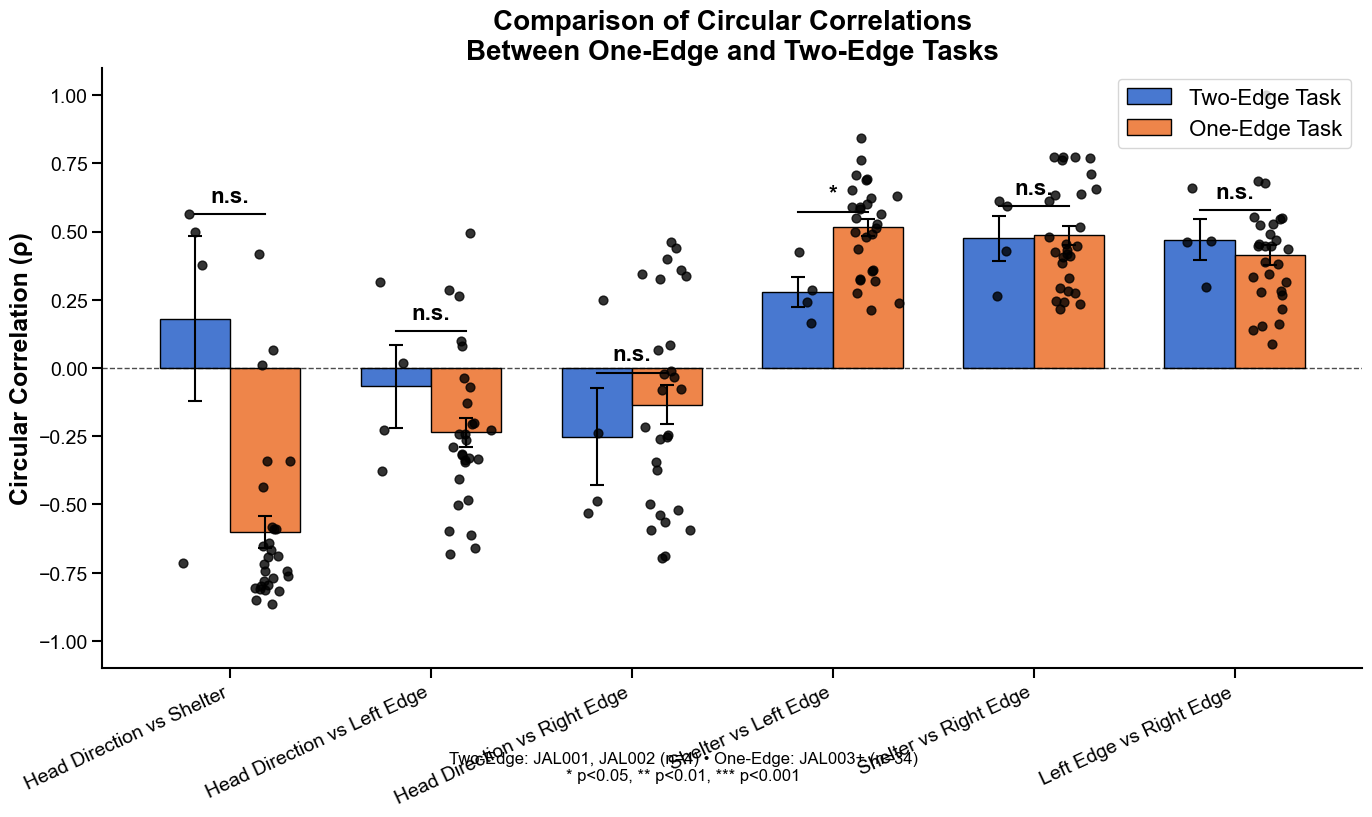

In [29]:
def compare_one_edge_vs_two_edge_correlations():
    """
    Compare circular correlations between one-edge tasks (JAL003+) and two-edge tasks (JAL001, JAL002).
    Creates a visualization showing differences in circular correlations between task types.
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import scipy.stats as stats
    from itertools import combinations
    import polars as pl
    
    # Find all session paths
    all_sessions = find_all_sessions()
    
    # Separate into two-edge (JAL001, JAL002) and one-edge tasks (all others)
    two_edge_sessions = [s for s in all_sessions if "JAL001" in s or "JAL002" in s]
    one_edge_sessions = [s for s in all_sessions if "JAL001" not in s and "JAL002" not in s]
    
    print(f"Found {len(two_edge_sessions)} two-edge sessions and {len(one_edge_sessions)} one-edge sessions")
    
    # Define angles we're interested in analyzing
    angles_without_center = ['hdir', 'hsa', 'h_postflipbar_a', 'h_preflipbar_a']
    
    # Create display names for better readability
    display_names = {
        'hdir': 'Head Direction',
        'hsa': 'Shelter',
        'h_postflipbar_a': 'Left Edge',
        'h_preflipbar_a': 'Right Edge'
    }
    
    # Generate all possible pairs of angles
    perms = list(combinations(angles_without_center, 2))
    
    # Process two-edge sessions
    two_edge_rhos = []
    print("\nProcessing two-edge sessions...")
    for session_path in two_edge_sessions:
        try:
            # Try to load the full video dataframe
            video_df_path = os.path.join(session_path, "processed_data", "full_video_dataframe.csv")
            if os.path.exists(video_df_path):
                session_df = pl.read_csv(video_df_path)
                
                # Filter to barrier_present condition and calculate correlations
                data = filter_video_dataframe(session_df, "barrier_present")
                rho_dic = loop_permutations_apply_circcoeff(perms, data)
                two_edge_rhos.append(rho_dic)
                
                print(f"  Processed {os.path.basename(session_path)}")
            else:
                print(f"  Skipping {os.path.basename(session_path)} - no video dataframe found")
        except Exception as e:
            print(f"  Error processing {os.path.basename(session_path)}: {e}")
    
    # Process one-edge sessions
    one_edge_rhos = []
    print("\nProcessing one-edge sessions...")
    for session_path in one_edge_sessions:
        try:
            # Try to load the full video dataframe
            video_df_path = os.path.join(session_path, "processed_data", "full_video_dataframe.csv")
            if os.path.exists(video_df_path):
                session_df = pl.read_csv(video_df_path)
                
                # Filter to barrier_present condition and calculate correlations
                data = filter_video_dataframe(session_df, "barrier_present")
                rho_dic = loop_permutations_apply_circcoeff(perms, data)
                one_edge_rhos.append(rho_dic)
                
                print(f"  Processed {os.path.basename(session_path)}")
            else:
                print(f"  Skipping {os.path.basename(session_path)} - no video dataframe found")
        except Exception as e:
            print(f"  Error processing {os.path.basename(session_path)}: {e}")
    
    # For each pair, collect data and perform statistics
    pair_data = {}
    print("\nPair statistics:")
    for perm in perms:
        # Extract values for this pair across all sessions
        two_edge_vals = [session_rho.get(perm, np.nan) for session_rho in two_edge_rhos]
        one_edge_vals = [session_rho.get(perm, np.nan) for session_rho in one_edge_rhos]
        
        # Remove NaN values
        two_edge_vals = [v for v in two_edge_vals if not np.isnan(v)]
        one_edge_vals = [v for v in one_edge_vals if not np.isnan(v)]
        
        # Calculate mean and SEM
        two_edge_mean = np.mean(two_edge_vals) if two_edge_vals else np.nan
        one_edge_mean = np.mean(one_edge_vals) if one_edge_vals else np.nan
        
        two_edge_sem = np.std(two_edge_vals, ddof=1) / np.sqrt(len(two_edge_vals)) if len(two_edge_vals) > 1 else np.nan
        one_edge_sem = np.std(one_edge_vals, ddof=1) / np.sqrt(len(one_edge_vals)) if len(one_edge_vals) > 1 else np.nan
        
        # Perform t-test between conditions
        if len(two_edge_vals) > 1 and len(one_edge_vals) > 1:
            t_stat, p_val = stats.ttest_ind(two_edge_vals, one_edge_vals, equal_var=False)
        else:
            p_val = np.nan
        
        pair_data[perm] = {
            'two_edge_values': two_edge_vals,
            'two_edge_mean': two_edge_mean,
            'two_edge_sem': two_edge_sem,
            'one_edge_values': one_edge_vals,
            'one_edge_mean': one_edge_mean,
            'one_edge_sem': one_edge_sem,
            'p_value': p_val,
            'display_label': f"{display_names[perm[0]]} vs {display_names[perm[1]]}"
        }
        
        # Print result summary
        print(f"\nPair: {display_names[perm[0]]} vs {display_names[perm[1]]}")
        print(f"  Two-edge mean ± SEM: {two_edge_mean:.3f} ± {two_edge_sem:.3f} (n={len(two_edge_vals)})")
        print(f"  One-edge mean ± SEM: {one_edge_mean:.3f} ± {one_edge_sem:.3f} (n={len(one_edge_vals)})")
        if not np.isnan(p_val):
            print(f"  p-value: {p_val:.4f}")
            print(f"  Significant difference: {'Yes' if p_val < 0.05 else 'No'}")
        else:
            print("  Not enough data for statistical testing")
        print(f"  Two-edge values: {[f'{v:.3f}' for v in two_edge_vals]}")
        print(f"  One-edge values: {[f'{v:.3f}' for v in one_edge_vals]}")
    
    # Set up plotting parameters
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(perms))
    width = 0.35
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    })
    
    # Plot bars for each task type
    two_edge_bars = ax.bar(x - width/2, 
                       [pair_data[pair]['two_edge_mean'] for pair in perms], 
                       width, label='Two-Edge Task', color='#4878D0', edgecolor='black')
    
    one_edge_bars = ax.bar(x + width/2, 
                          [pair_data[pair]['one_edge_mean'] for pair in perms], 
                          width, label='One-Edge Task', color='#EE854A', edgecolor='black')
    
    # Add individual data points with jitter
    for i, pair in enumerate(perms):
        # Plot two-edge points
        x_jitter = np.random.normal(0, 0.05, size=len(pair_data[pair]['two_edge_values']))
        ax.scatter(x[i] - width/2 + x_jitter, 
                   pair_data[pair]['two_edge_values'], 
                   color='black', s=40, alpha=0.8, zorder=3)
        
        # Plot one-edge points
        x_jitter = np.random.normal(0, 0.05, size=len(pair_data[pair]['one_edge_values']))
        ax.scatter(x[i] + width/2 + x_jitter, 
                   pair_data[pair]['one_edge_values'], 
                   color='black', s=40, alpha=0.8, zorder=3)
    
    # Add error bars
    ax.errorbar(x - width/2, 
                [pair_data[pair]['two_edge_mean'] for pair in perms],
                yerr=[pair_data[pair]['two_edge_sem'] if not np.isnan(pair_data[pair]['two_edge_sem']) else 0 for pair in perms], 
                fmt='none', color='black', capsize=5, capthick=1.5, zorder=4)
    
    ax.errorbar(x + width/2, 
                [pair_data[pair]['one_edge_mean'] for pair in perms],
                yerr=[pair_data[pair]['one_edge_sem'] if not np.isnan(pair_data[pair]['one_edge_sem']) else 0 for pair in perms], 
                fmt='none', color='black', capsize=5, capthick=1.5, zorder=4)
    
    # Add statistical significance indicators
    for i, pair in enumerate(perms):
        if not np.isnan(pair_data[pair]['p_value']):
            p = pair_data[pair]['p_value']
            y_pos = max(
                pair_data[pair]['two_edge_mean'] + (pair_data[pair]['two_edge_sem'] if not np.isnan(pair_data[pair]['two_edge_sem']) else 0) * 1.2,
                pair_data[pair]['one_edge_mean'] + (pair_data[pair]['one_edge_sem'] if not np.isnan(pair_data[pair]['one_edge_sem']) else 0) * 1.2
            ) + 0.05
            
            # Add significance stars
            if p < 0.001:
                sig = "***"
            elif p < 0.01:
                sig = "**"
            elif p < 0.05:
                sig = "*"
            else:
                sig = "n.s."
            
            # Add connector line for all results
            ax.plot([x[i] - width/2, x[i] + width/2], 
                    [y_pos - 0.03, y_pos - 0.03], 
                    'k-', linewidth=1.5)
            ax.text(x[i], y_pos, sig, ha='center', va='bottom', 
                    fontweight='bold', fontsize=16)
    
    # Configure axes
    ax.set_ylabel('Circular Correlation (ρ)', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([pair_data[pair]['display_label'] for pair in perms], rotation=25, ha='right', fontsize=14)
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=7)
    
    # Add legend
    ax.legend(fontsize=16, frameon=True, loc='upper right')
    
    # Add title
    ax.set_title('Comparison of Circular Correlations\nBetween One-Edge and Two-Edge Tasks', 
                fontsize=20, fontweight='bold')
    
    # Add note about sessions
    plt.figtext(0.5, 0.01, 
                f'Two-Edge: JAL001, JAL002 (n={len(two_edge_rhos)}) • One-Edge: JAL003+ (n={len(one_edge_rhos)})\n* p<0.05, ** p<0.01, *** p<0.001', 
                ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    # Save figure
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "one_edge_vs_two_edge_comparison.eps"), 
               format="eps", bbox_inches="tight", dpi=300)
    plt.savefig(os.path.join(save_path, "one_edge_vs_two_edge_comparison.png"), 
               format="png", bbox_inches="tight", dpi=300)
    plt.savefig(os.path.join(save_path, "one_edge_vs_two_edge_comparison.pdf"), 
               format="pdf", bbox_inches="tight", dpi=300)
    
    print("\nFigure saved to:", save_path)
    return fig, ax, pair_data, two_edge_rhos, one_edge_rhos

# Call the function to run the analysis
fig, ax, pair_data, two_edge_rhos, one_edge_rhos = compare_one_edge_vs_two_edge_correlations()